# Random Forest Prediction of EPVI Indicators

This notebook trains one random forest model per EPVI indicator from satellite-derived freguesia indicators and only the **basic** administrative indicators listed in `data/adm_data_split.json`.

It reads the fixed test set and spatial-CV fold assignments from `data/spatial_split_assignments.csv`, which is generated by `spatial_test_set_selection.ipynb`. Run that notebook through the split-assignment cell before rerunning model training.

The privately shared EPVI file stays outside git. Detailed administrative indicators remain excluded here; they are reserved for residual analysis.

Model selection now uses the saved spatial-CV folds from `data/spatial_split_assignments.csv`. The fixed holdout chosen in `spatial_test_set_selection.ipynb` is removed before tuning and is used only for final performance estimates.


In [5]:
from __future__ import annotations

import json
import sys
import time
from datetime import datetime
from importlib import import_module, reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42


In [6]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
attach_nuts3 = rf_utils.attach_nuts3
build_modeling_table = rf_utils.build_modeling_table
choose_satellite_csv = rf_utils.choose_satellite_csv
id_coverage_summary = rf_utils.id_coverage_summary
load_nuts3_mapping = rf_utils.load_nuts3_mapping
load_prediction_inputs = rf_utils.load_prediction_inputs
load_spatial_split_assignments = rf_utils.load_spatial_split_assignments
apply_spatial_split_assignments = rf_utils.apply_spatial_split_assignments
make_precomputed_cv_splits = rf_utils.make_precomputed_cv_splits
rmse = rf_utils.rmse
spearman_corr = rf_utils.spearman_corr

PATHS = load_paths()
SAT_CSV, REGENERATED_SAT_CSV, SNAPSHOT_SAT_CSV = choose_satellite_csv(PATHS, repo_data_path, path_value)
ADM_CSV = repo_data_path(PATHS, "all_used_adm_indicators.csv")
ADM_SPLIT_JSON = repo_data_path(PATHS, "adm_data_split.json")
NUTS3_MAPPING_CSV = repo_data_path(PATHS, "freguesias_to_NUTS3.csv")
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")
SPATIAL_SPLIT_ASSIGNMENTS_CSV = repo_data_path(PATHS, "spatial_split_assignments.csv")
EPVI_CSV = path_value(PATHS, "epvi_csv")
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Scope switch for robustness checks.
# False keeps mainland Portugal, Azores, and Madeira. True drops PT200/PT300
# before train/test splitting, spatial CV fold creation, model fitting, and maps.
EXCLUDE_OVERSEAS_TERRITORIES = True
OVERSEAS_NUTS3 = tuple(rf_utils.OVERSEAS_NUTS3)
MODEL_SCOPE_LABEL = "mainland_only" if EXCLUDE_OVERSEAS_TERRITORIES else "all_territories"

print("repo:", REPO_ROOT)
print("satellite predictors:", SAT_CSV)
if SAT_CSV == SNAPSHOT_SAT_CSV:
    print("WARNING: regenerated external index CSV was not found; using committed satellite snapshot.")
print("administrative predictors:", ADM_CSV)
print("private EPVI targets:", EPVI_CSV)
print("NUTS3 mapping:", NUTS3_MAPPING_CSV)
print("parish geometry snapshot:", PARISH_GEOMETRY_GEOJSON)
print("saved spatial split assignments:", SPATIAL_SPLIT_ASSIGNMENTS_CSV)
print("model outputs:", MODEL_OUT_DIR)
print("model scope:", MODEL_SCOPE_LABEL)
if EXCLUDE_OVERSEAS_TERRITORIES:
    print("excluding overseas NUTS3 regions:", OVERSEAS_NUTS3)


repo: e:\git_projects\energy_poverty_from_space
satellite predictors: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\indices\freguesia_indices_streaming.csv
administrative predictors: E:\git_projects\energy_poverty_from_space\data\all_used_adm_indicators.csv
private EPVI targets: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\EPVI_results_gouveia_et_al_2019.csv
NUTS3 mapping: E:\git_projects\energy_poverty_from_space\data\freguesias_to_NUTS3.csv
parish geometry snapshot: E:\git_projects\energy_poverty_from_space\data\parishes.geojson
saved spatial split assignments: E:\git_projects\energy_poverty_from_space\data\spatial_split_assignments.csv
model outputs: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest
model scope: mainland_only
excluding overseas NUTS3 regions: ('PT200', 'PT300')


In [7]:
inputs = load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=ADM_CSV,
    epvi_csv=EPVI_CSV,
    adm_split_json=ADM_SPLIT_JSON,
)

EPVI_TARGETS = inputs["targets"]
model_df, predictor_cols, constant_cols = build_modeling_table(inputs)
nuts3_mapping = load_nuts3_mapping(NUTS3_MAPPING_CSV)
model_df = attach_nuts3(model_df, nuts3_mapping)
if EXCLUDE_OVERSEAS_TERRITORIES:
    before_scope_rows = len(model_df)
    model_df = model_df.loc[~model_df["NUTS3"].isin(OVERSEAS_NUTS3)].copy()
    print(f"Excluded {before_scope_rows - len(model_df)} overseas rows from modeling table.")

scope_constant_cols = [c for c in predictor_cols if model_df[c].nunique(dropna=True) <= 1]
if scope_constant_cols:
    predictor_cols = [c for c in predictor_cols if c not in scope_constant_cols]
    constant_cols = [*constant_cols, *scope_constant_cols]

if not SPATIAL_SPLIT_ASSIGNMENTS_CSV.exists():
    raise FileNotFoundError(
        f"Saved split assignment file not found: {SPATIAL_SPLIT_ASSIGNMENTS_CSV}. "
        "Run pipeline/3_epvi_prediction/spatial_test_set_selection.ipynb through the 'Write Split Assignments' cell first."
    )

split_assignments = load_spatial_split_assignments(SPATIAL_SPLIT_ASSIGNMENTS_CSV)
model_df, train_df, test_df = apply_spatial_split_assignments(model_df, split_assignments)
selected_test_nuts3 = tuple(sorted(test_df["NUTS3"].astype(str).unique()))

print("Raw input ID coverage:")
display(id_coverage_summary(inputs))
print("model scope:", MODEL_SCOPE_LABEL)
print("targets:", EPVI_TARGETS)
print("Final modeling rows:", len(model_df))
print("Training rows from saved split assignments:", len(train_df))
print("Fixed test rows from saved split assignments:", len(test_df))
print("Training NUTS3 regions:", train_df["NUTS3"].nunique())
print("Test NUTS3 regions:", list(selected_test_nuts3))
print("Saved training CV folds:", sorted(train_df["spatial_cv_fold"].unique()))
print("Predictors used after dropping constant/all-missing columns:", len(predictor_cols))
print("Dropped constant/all-missing predictors:", constant_cols)
display(model_df[["ID_norm", "NUTS3", "spatial_split_role", "spatial_cv_fold", "parish_name", *EPVI_TARGETS]].head())
display(model_df[predictor_cols].isna().mean().sort_values(ascending=False).rename("missing_share").head(20).to_frame())


Excluded 210 overseas rows from modeling table.
Raw input ID coverage:


,table,rows,unique_ids,duplicate_ids,missing_ids
0,sat,3092.0,3092,0.0,0.0
1,adm,3093.0,3092,0.0,1.0
2,epvi,3092.0,3092,0.0,0.0
3,common_sat_adm_epvi,NaN,3092,NaN,NaN


model scope: mainland_only
targets: ['EPG heating', 'EPG cooling', 'AIAM', 'EPVI heating', 'EPVI cooling']
Final modeling rows: 2882
Training rows from saved split assignments: 2309
Fixed test rows from saved split assignments: 573
Training NUTS3 regions: 19
Test NUTS3 regions: ['PT112', 'PT16J', 'PT185', 'PT187']
Saved training CV folds: [0, 1, 2, 3, 4]
Predictors used after dropping constant/all-missing columns: 47
Dropped constant/all-missing predictors: ['res_vol_per_capita_p10', 'pop_density_p10', 'ntl_per_res_vol_p10', 'ntl_per_res_vol_p50', 'energy_per_vol_per_capita_p10', 'pop_density_p50']


,ID_norm,NUTS3,spatial_split_role,spatial_cv_fold,parish_name,EPG heating,EPG cooling,AIAM,EPVI heating,EPVI cooling
0,010103,PT16D,training,3.0,Aguada de Cima,15,19,13.4,10.8,12.8
1,010109,PT16D,training,3.0,Fermentelos,16,19,13.4,11.3,12.8
2,010112,PT16D,training,3.0,Macinhata do Vouga,16,19,12.4,11.8,13.3
3,010119,PT16D,training,3.0,Valongo do Vouga,16,19,13.8,11.1,12.6
4,010121,PT16D,training,3.0,União das Freguesias de Águeda e Borralha,14,20,13.1,10.5,13.5


,missing_share
extreme_cold,0.040944
extreme_heat,0.040944
cdd_25,0.040944
hdd_18,0.040944
res_ratio,0.000000
delta_bc,0.000000
ntl_per_res_vol_gini,0.000000
energy_per_vol_per_capita_p50,0.000000
energy_per_vol_per_capita_p90,0.000000
energy_per_vol_per_capita_gini,0.000000


## Spatial Split Map

This map shows the fixed spatial test set and the training-region NUTS3 folds used for hyperparameter search. Every parish in one NUTS3 region has the same split label.


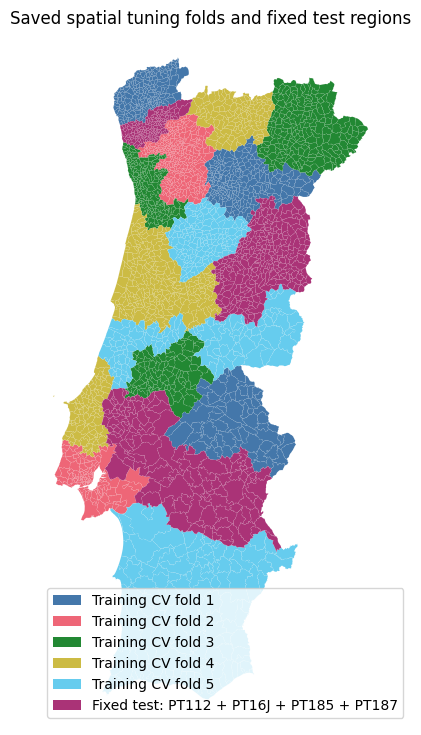

,fold,n_rows,n_nuts3,validation_nuts3
0,0,494,3,"PT111, PT11D, PT186"
1,1,463,3,"PT119, PT11C, PT170"
2,2,461,3,"PT11A, PT11E, PT16I"
3,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


In [8]:
split_template_df = train_df.reset_index(drop=True)
_, split_fold_summary = make_precomputed_cv_splits(split_template_df, fold_col="spatial_cv_fold")

split_labels = model_df[["ID_norm", "NUTS3", "spatial_split_label"]].drop_duplicates().copy()
test_label = "Fixed test: " + " + ".join(selected_test_nuts3)
split_labels["split_label"] = split_labels["spatial_split_label"].replace({"Fixed test": test_label})

parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
split_map = parishes.merge(split_labels[["ID_norm", "NUTS3", "split_label"]], on="ID_norm", how="inner")
if split_map["split_label"].isna().any():
    raise ValueError(f"Split map is missing labels for {split_map['split_label'].isna().sum()} parish geometries.")

saved_cv_folds = sorted(int(fold) for fold in split_template_df["spatial_cv_fold"].dropna().unique())
fold_labels = [f"Training CV fold {fold + 1}" for fold in saved_cv_folds]
split_order = [*fold_labels, test_label]
split_colors = {
    **{label: color for label, color in zip(fold_labels, ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE"])},
    test_label: "#AA3377",
}

def plot_split_regions(ax, gdf):
    if gdf.empty:
        ax.set_axis_off()
        return
    for label in split_order:
        part = gdf.loc[gdf["split_label"].eq(label)]
        if part.empty:
            continue
        part.plot(
            ax=ax,
            color=split_colors[label],
            edgecolor="white",
            linewidth=0.03,
        )
    bounds = np.asarray(gdf.total_bounds, dtype=float)
    if not np.isfinite(bounds).all():
        ax.set_axis_off()
        return
    minx, miny, maxx, maxy = bounds
    padx = max((maxx - minx) * 0.04, 0.01)
    pady = max((maxy - miny) * 0.04, 0.01)
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_xticks([])
    ax.set_yticks([])

mainland_map = split_map.loc[~split_map["NUTS3"].isin(["PT200", "PT300"])].copy()
azores_map = split_map.loc[split_map["NUTS3"].eq("PT200")].copy()
madeira_map = split_map.loc[split_map["NUTS3"].eq("PT300")].copy()

if EXCLUDE_OVERSEAS_TERRITORIES:
    fig, ax_main = plt.subplots(figsize=(7, 9))
    plot_split_regions(ax_main, mainland_map)
    ax_main.set_title("Saved spatial tuning folds and fixed test regions")
    ax_main.set_facecolor("white")
    ax_main.set_axis_off()
    ax_main.legend(
        handles=[Patch(facecolor=split_colors[label], edgecolor="none", label=label) for label in split_order],
        loc="lower left",
        frameon=True,
    )
else:
    fig = plt.figure(figsize=(10, 10))
    ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
    ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
    ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)

    plot_split_regions(ax_main, mainland_map)
    plot_split_regions(ax_azores, azores_map)
    plot_split_regions(ax_madeira, madeira_map)
    ax_main.set_title("Saved spatial tuning folds and fixed test regions")
    ax_azores.set_title("Azores", fontsize=10)
    ax_madeira.set_title("Madeira", fontsize=10)
    for ax in [ax_main, ax_azores, ax_madeira]:
        ax.set_facecolor("white")
    ax_main.set_axis_off()
    for ax in [ax_azores, ax_madeira]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.0)
    ax_main.legend(
        handles=[Patch(facecolor=split_colors[label], edgecolor="none", label=label) for label in split_order],
        loc="lower left",
        frameon=True,
    )
plt.show()

display(split_fold_summary)


## Modeling Design

This notebook runs the first broad spatial tuning pass for the selected model scope.

The search is intentionally broad because changing `EXCLUDE_OVERSEAS_TERRITORIES` changes the training distribution and the NUTS3 folds. Target-aware narrowed searches from another scope should be treated as history, not as the starting point for a new robustness run.

For each target, hyperparameters are searched only on training NUTS3 regions. Validation folds hold out whole NUTS3 regions and the fold builder keeps `PT200` and `PT300` in different folds when both are present. If overseas territories are excluded, those regions are removed before fold creation. After tuning, the selected model is evaluated in two distinct ways:

- spatial out-of-fold predictions inside the training regions, used as a tuning diagnostic;
- one final fit on all training regions and one prediction on the fixed representative test set, used for performance analysis.


In [9]:
SPATIAL_CV_FOLDS = 5

preprocess = ColumnTransformer(
    transformers=[("num", SimpleImputer(strategy="median"), predictor_cols)],
    remainder="drop",
    verbose_feature_names_out=False,
)
pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True)),
])

# First pass for a new model scope: keep one broad space across targets.
broad_search_space = {
    "model__n_estimators": [300, 500, 800],
    "model__max_features": ["sqrt", 0.35, 0.5, 0.75, 1.0],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_depth": [None, 8, 12, 18, 24, 32],
}
param_distributions_by_target = {target: broad_search_space for target in EPVI_TARGETS}
search_candidates_by_target = {target: 40 for target in EPVI_TARGETS}

print("Spatial CV folds:", SPATIAL_CV_FOLDS)
for target in EPVI_TARGETS:
    candidate_space = len(ParameterGrid(param_distributions_by_target[target]))
    n_candidates = search_candidates_by_target[target]
    print(f"{target}: random candidates={n_candidates} | candidate space={candidate_space} | spatial-CV fits={n_candidates * SPATIAL_CV_FOLDS}")


Spatial CV folds: 5
EPG heating: random candidates=40 | candidate space=1800 | spatial-CV fits=200
EPG cooling: random candidates=40 | candidate space=1800 | spatial-CV fits=200
AIAM: random candidates=40 | candidate space=1800 | spatial-CV fits=200
EPVI heating: random candidates=40 | candidate space=1800 | spatial-CV fits=200
EPVI cooling: random candidates=40 | candidate space=1800 | spatial-CV fits=200


In [10]:
def fmt_seconds(seconds: float) -> str:
    seconds = int(round(seconds))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f"{hours}h {minutes}m {secs}s"
    if minutes:
        return f"{minutes}m {secs}s"
    return f"{secs}s"


def metric_row(prefix: str, y_true, y_pred) -> dict[str, float]:
    return {
        f"{prefix}_r2": r2_score(y_true, y_pred),
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
        f"{prefix}_rmse": rmse(y_true, y_pred),
        f"{prefix}_spearman": spearman_corr(y_true, y_pred),
    }

metrics = []
prediction_frames = []
importance_frames = []
fold_frames = []
best_params = {}
all_started = time.perf_counter()

for target_idx, target in enumerate(EPVI_TARGETS, start=1):
    target_started = time.perf_counter()
    train_t = train_df.dropna(subset=[target]).copy().reset_index(drop=True)
    test_t = test_df.dropna(subset=[target]).copy().reset_index(drop=True)
    spatial_cv, fold_summary = make_precomputed_cv_splits(train_t, fold_col="spatial_cv_fold")
    fold_summary.insert(0, "target", target)
    fold_summary.insert(0, "model_scope", MODEL_SCOPE_LABEL)
    fold_frames.append(fold_summary)

    X_train = train_t[predictor_cols]
    y_train = train_t[target].astype(float)
    X_test = test_t[predictor_cols]
    y_test = test_t[target].astype(float)

    param_distributions = param_distributions_by_target[target]
    search_candidates = search_candidates_by_target[target]

    print("=" * 96, flush=True)
    print(f"[{target_idx}/{len(EPVI_TARGETS)}] Target: {target}", flush=True)
    print(
        f"Train rows={len(train_t):,} | test rows={len(test_t):,} | predictors={len(predictor_cols):,} | "
        f"NUTS3 CV folds={len(spatial_cv)} | search fits={search_candidates * len(spatial_cv):,}",
        flush=True,
    )
    display(fold_summary)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=search_candidates,
        scoring="r2",
        cv=spatial_cv,
        n_jobs=-1,
        refit=True,
        verbose=2,
        random_state=RANDOM_STATE,
    )
    print(f"Starting spatial hyperparameter search at {datetime.now().strftime('%H:%M:%S')}...", flush=True)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    best_params[target] = search.best_params_
    print(f"Best mean spatial-CV search R2={search.best_score_:.4f}", flush=True)
    print("Best params:", best_params[target], flush=True)

    print("Computing spatial out-of-fold predictions on training regions...", flush=True)
    cv_pred = cross_val_predict(best, X_train, y_train, cv=spatial_cv, n_jobs=-1)
    print("Refitting selected model on all training regions and predicting fixed test regions...", flush=True)
    best.fit(X_train, y_train)
    train_pred = best.predict(X_train)
    test_pred = best.predict(X_test)

    row = {
        "target": target,
        "model_scope": MODEL_SCOPE_LABEL,
        "exclude_overseas_territories": EXCLUDE_OVERSEAS_TERRITORIES,
        "n_train_rows": len(train_t),
        "n_test_rows": len(test_t),
        "n_predictors": len(predictor_cols),
        "search_spatial_cv_r2_mean": search.best_score_,
        **metric_row("train_spatial_cv", y_train, cv_pred),
        **metric_row("fixed_test", y_test, test_pred),
        **metric_row("train_in_sample", y_train, train_pred),
    }
    metrics.append(row)

    for role, data, observed, predicted in [
        ("train_spatial_cv", train_t, y_train, cv_pred),
        ("fixed_test", test_t, y_test, test_pred),
        ("train_in_sample", train_t, y_train, train_pred),
    ]:
        prediction_frames.append(pd.DataFrame({
            "prediction_role": role,
            "model_scope": MODEL_SCOPE_LABEL,
            "target": target,
            "ID": data["ID"].values,
            "ID_norm": data["ID_norm"].values,
            "NUTS3": data["NUTS3"].values,
            "name": data["parish_name"].values,
            "observed": observed.values,
            "predicted": predicted,
            "residual": observed.values - predicted,
        }))

    importance_frames.append(pd.DataFrame({
        "model_scope": MODEL_SCOPE_LABEL,
        "target": target,
        "feature": predictor_cols,
        "impurity_importance": best.named_steps["model"].feature_importances_,
    }).sort_values("impurity_importance", ascending=False))

    target_seconds = time.perf_counter() - target_started
    elapsed_total = time.perf_counter() - all_started
    remaining = elapsed_total / target_idx * (len(EPVI_TARGETS) - target_idx)
    print(pd.Series(row).to_string(), flush=True)
    print(f"Finished in {fmt_seconds(target_seconds)}. Elapsed={fmt_seconds(elapsed_total)} | ETA={fmt_seconds(remaining)}", flush=True)

metrics_df = pd.DataFrame(metrics).sort_values("fixed_test_r2", ascending=False)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
importances_df = pd.concat(importance_frames, ignore_index=True)
folds_df = pd.concat(fold_frames, ignore_index=True)
display(metrics_df)


[1/5] Target: EPG heating
Train rows=2,309 | test rows=573 | predictors=47 | NUTS3 CV folds=5 | search fits=200


,model_scope,target,fold,n_rows,n_nuts3,validation_nuts3
0,mainland_only,EPG heating,0,494,3,"PT111, PT11D, PT186"
1,mainland_only,EPG heating,1,463,3,"PT119, PT11C, PT170"
2,mainland_only,EPG heating,2,461,3,"PT11A, PT11E, PT16I"
3,mainland_only,EPG heating,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,mainland_only,EPG heating,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


Starting spatial hyperparameter search at 19:27:13...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best mean spatial-CV search R2=0.1756
Best params: {'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 12, 'model__max_features': 'sqrt', 'model__max_depth': 24}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                            EPG heating
model_scope                     mainland_only
exclude_overseas_territories             True
n_train_rows                             2309
n_test_rows                               573
n_predictors                               47
search_spatial_cv_r2_mean            0.175619
train_spatial_cv_r2                  0.290034
train_spatial_cv_mae                 1.069925
train_spatial_cv_rmse                1.570748
train_spatial_cv_spearman            0.477017
fixed_test_r2                 

,model_scope,target,fold,n_rows,n_nuts3,validation_nuts3
0,mainland_only,EPG cooling,0,494,3,"PT111, PT11D, PT186"
1,mainland_only,EPG cooling,1,463,3,"PT119, PT11C, PT170"
2,mainland_only,EPG cooling,2,461,3,"PT11A, PT11E, PT16I"
3,mainland_only,EPG cooling,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,mainland_only,EPG cooling,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


Starting spatial hyperparameter search at 19:34:08...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best mean spatial-CV search R2=-0.0261
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.35, 'model__max_depth': 32}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                            EPG cooling
model_scope                     mainland_only
exclude_overseas_territories             True
n_train_rows                             2309
n_test_rows                               573
n_predictors                               47
search_spatial_cv_r2_mean           -0.026069
train_spatial_cv_r2                  0.261566
train_spatial_cv_mae                 0.688023
train_spatial_cv_rmse                0.957662
train_spatial_cv_spearman            0.438367
fixed_test_r2                   

...

,model_scope,target,fold,n_rows,n_nuts3,validation_nuts3
0,mainland_only,EPVI heating,0,494,3,"PT111, PT11D, PT186"
1,mainland_only,EPVI heating,1,463,3,"PT119, PT11C, PT170"
2,mainland_only,EPVI heating,2,461,3,"PT11A, PT11E, PT16I"
3,mainland_only,EPVI heating,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,mainland_only,EPVI heating,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


Starting spatial hyperparameter search at 19:48:24...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best mean spatial-CV search R2=0.4222
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 24}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                           EPVI heating
model_scope                     mainland_only
exclude_overseas_territories             True
n_train_rows                             2309
n_test_rows                               573
n_predictors                               47
search_spatial_cv_r2_mean            0.422245
train_spatial_cv_r2                  0.473299
train_spatial_cv_mae                  0.59963
train_spatial_cv_rmse                0.862771
train_spatial_cv_spearman            0.706475
fixed_test_r2                     

,model_scope,target,fold,n_rows,n_nuts3,validation_nuts3
0,mainland_only,EPVI cooling,0,494,3,"PT111, PT11D, PT186"
1,mainland_only,EPVI cooling,1,463,3,"PT119, PT11C, PT170"
2,mainland_only,EPVI cooling,2,461,3,"PT11A, PT11E, PT16I"
3,mainland_only,EPVI cooling,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,mainland_only,EPVI cooling,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


Starting spatial hyperparameter search at 19:55:17...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best mean spatial-CV search R2=0.4616
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 32}
Computing spatial out-of-fold predictions on training regions...
Refitting selected model on all training regions and predicting fixed test regions...
target                           EPVI cooling
model_scope                     mainland_only
exclude_overseas_territories             True
n_train_rows                             2309
n_test_rows                               573
n_predictors                               47
search_spatial_cv_r2_mean            0.461648
train_spatial_cv_r2                  0.520167
train_spatial_cv_mae                 0.422178
train_spatial_cv_rmse                0.554784
train_spatial_cv_spearman             0.72056
fixed_test_r2                     

,target,model_scope,exclude_overseas_territories,n_train_rows,n_test_rows,n_predictors,search_spatial_cv_r2_mean,train_spatial_cv_r2,train_spatial_cv_mae,train_spatial_cv_rmse,train_spatial_cv_spearman,fixed_test_r2,fixed_test_mae,fixed_test_rmse,fixed_test_spearman,train_in_sample_r2,train_in_sample_mae,train_in_sample_rmse,train_in_sample_spearman
2,AIAM,mainland_only,True,2309,573,47,0.884277,0.884791,0.250986,0.349435,0.940613,0.880964,0.225797,0.310252,0.932169,0.953099,0.164736,0.222955,0.971744
4,EPVI cooling,mainland_only,True,2309,573,47,0.461648,0.520167,0.422178,0.554784,0.720560,0.636405,0.337625,0.425462,0.793961,0.951606,0.124263,0.176187,0.980402
1,EPG cooling,mainland_only,True,2309,573,47,-0.026069,0.261566,0.688023,0.957662,0.438367,0.414134,0.581476,0.773015,0.608541,0.958871,0.146490,0.226012,0.948418
3,EPVI heating,mainland_only,True,2309,573,47,0.422245,0.473299,0.599630,0.862771,0.706475,0.322574,0.499144,0.740377,0.606311,0.887724,0.246529,0.398344,0.954771
0,EPG heating,mainland_only,True,2309,573,47,0.175619,0.290034,1.069925,1.570748,0.477017,0.033316,0.906419,1.385323,0.192240,0.649169,0.708395,1.104172,0.801460


In [11]:
# Optional feature importance diagnostic evaluated on the fixed test set.
RUN_PERMUTATION_IMPORTANCE = False
permutation_frames = []
if RUN_PERMUTATION_IMPORTANCE:
    for target in EPVI_TARGETS:
        train_t = train_df.dropna(subset=[target]).copy()
        test_t = test_df.dropna(subset=[target]).copy()
        best = Pipeline([
            ("prep", preprocess),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True, **{
                key.replace("model__", ""): value for key, value in best_params[target].items()
            })),
        ])
        best.fit(train_t[predictor_cols], train_t[target].astype(float))
        perm = permutation_importance(
            best,
            test_t[predictor_cols],
            test_t[target].astype(float),
            scoring="r2",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        permutation_frames.append(pd.DataFrame({
            "target": target,
            "feature": predictor_cols,
            "permutation_importance_mean": perm.importances_mean,
            "permutation_importance_std": perm.importances_std,
        }).sort_values("permutation_importance_mean", ascending=False))
permutation_df = pd.concat(permutation_frames, ignore_index=True) if permutation_frames else pd.DataFrame()
if not permutation_df.empty:
    display(permutation_df.groupby("target").head(15))


In [12]:
stamp = f"{MODEL_SCOPE_LABEL}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
metrics_path = MODEL_OUT_DIR / f"rf_epvi_metrics_{stamp}.csv"
predictions_path = MODEL_OUT_DIR / f"rf_epvi_predictions_residuals_{stamp}.csv"
importances_path = MODEL_OUT_DIR / f"rf_epvi_feature_importances_{stamp}.csv"
params_path = MODEL_OUT_DIR / f"rf_epvi_best_params_{stamp}.json"
folds_path = MODEL_OUT_DIR / f"rf_epvi_spatial_cv_folds_{stamp}.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
importances_df.to_csv(importances_path, index=False)
folds_df.to_csv(folds_path, index=False)
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)

if not permutation_df.empty:
    permutation_path = MODEL_OUT_DIR / f"rf_epvi_permutation_importances_{stamp}.csv"
    permutation_df.to_csv(permutation_path, index=False)
else:
    permutation_path = None

print("Wrote:")
for path in [metrics_path, predictions_path, importances_path, params_path, folds_path, permutation_path]:
    if path is not None:
        print(" -", path)


Wrote:
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_mainland_only_20260527_200201.json
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_mainland_only_20260527_200201.csv


## Next Step

Use the fixed-test metrics for model performance reporting. Use the training-region spatial-CV metrics to decide whether another narrower tuning pass is warranted, and inspect fixed-test residuals before moving detailed administrative indicators into the residual-explanation stage.
